# Customer Analytics Dataset - Exploratory Data Analysis

This project analyzes a customer analytics dataset to understand customer behavior,
income distribution, spending habits, and other demographic insights.

Each row represents one customer and includes demographic details,
income information, and purchase behavior.

In [1]:
# Phase 1 — Data Inspection

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/customer_analytics.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Check dataset structure
print("\nDataset info:")
df.info()

# Statistical summary
print("\nStatistical summary:")
df.describe()

First 5 rows of the dataset:


,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    str    
 3   City                  255 non-null    str    
 4   Education             243 non-null    str    
 5   MaritalStatus         255 non-null    str    
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    str    
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 35.6 KB

Statistical sum

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


## Phase 2 — Data Cleaning

In this phase, we check for missing values and duplicate records.
Data cleaning ensures accurate and reliable analysis.

In [2]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

We checked for missing values in the dataset.

Columns with missing values will be cleaned using
either filling with median/mean or removing the column if necessary.

In [3]:
df[df['Education'].isnull()]

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
23,1024,46,Male,Hyderabad,NaN,Single,113174.0,55,19,11,25,2,Tablet,4996
30,1031,23,Male,Mumbai,NaN,Single,474327.0,5,1,11,22,0,Tablet,1945
32,1033,53,Female,Mumbai,NaN,Married,54976.0,32,30,24,22,2,Laptop,4996
40,1041,46,Female,Delhi,NaN,Married,419963.0,5,24,7,28,0,Desktop,4631
44,1045,53,Male,Pune,NaN,Married,55693.0,59,26,7,7,3,Mobile,1376
85,1086,47,Female,Mumbai,NaN,Married,64611.0,57,25,1,8,3,Tablet,3677
91,1092,46,Female,Chennai,NaN,Married,71149.0,11,21,9,15,1,Tablet,2796
146,1147,46,Male,Pune,NaN,Married,78592.0,47,26,21,25,1,Mobile,890
160,1161,38,Female,Delhi,NaN,Married,114713.0,27,13,9,17,3,Mobile,2433
199,1200,45,Female,Chennai,NaN,Single,90940.0,37,25,1,7,3,Desktop,4523


In [4]:
df[df['AnnualIncome'].isnull()]

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
10,1011,44,Female,Mumbai,Masters,Married,NaN,56,24,3,5,0,Laptop,4974
12,1013,43,Female,Delhi,PhD,Single,NaN,27,18,22,10,2,Tablet,2070
22,1023,22,Male,Pune,Masters,Single,NaN,46,1,1,3,2,Laptop,2207
64,1065,37,Male,Chennai,Masters,Married,NaN,64,13,10,10,0,Mobile,3493
111,1112,26,Female,Delhi,PhD,Married,NaN,27,1,20,12,4,Mobile,2535
113,1114,42,Male,Pune,Masters,Married,NaN,49,21,22,3,4,Desktop,3728
154,1155,50,Male,Chennai,Bachelors,Married,NaN,13,30,17,3,2,Desktop,4000
163,1164,28,Female,Bangalore,Bachelors,Married,NaN,73,6,5,8,3,Mobile,2211
164,1165,33,Female,Chennai,Bachelors,Single,NaN,46,10,3,21,1,Desktop,4430
178,1179,45,Female,Delhi,PhD,Married,NaN,5,25,3,9,4,Mobile,1459


In [5]:
df.isnull().sum().sum()

np.int64(24)

In [7]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percentage.round(2)
})

,Missing Count,Missing %
CustomerID,0,0.00
Age,0,0.00
Gender,0,0.00
City,0,0.00
Education,12,4.71
MaritalStatus,0,0.00
AnnualIncome,12,4.71
SpendingScore,0,0.00
YearsEmployed,0,0.00
PurchaseFrequency,0,0.00


The dataset contains missing values in Education and AnnualIncome. Other columns have no missing values. Since the percentage of missing data is small (~5%), it is reasonable to impute rather than drop rows.

In [8]:
# Create a quick summary for your 'reports/' folder
null_counts = df.isnull().sum()
report_lines = [
    "DATASET CHARACTERISTICS REPORT",
    "===============================",
    f"Total Rows: {df.shape[0]}",
    f"Total Columns: {df.shape[1]}",
    "\nColumn Quality:",
]

for col in df.columns:
    null_pct = (null_counts[col] / len(df)) * 100
    report_lines.append(f"{col:<20} | Missing: {null_counts[col]} ({null_pct:.1f}%)")

# Print to console for immediate insight
print("\n".join(report_lines))

DATASET CHARACTERISTICS REPORT
Total Rows: 255
Total Columns: 14

Column Quality:
CustomerID           | Missing: 0 (0.0%)
Age                  | Missing: 0 (0.0%)
Gender               | Missing: 0 (0.0%)
City                 | Missing: 0 (0.0%)
Education            | Missing: 12 (4.7%)
MaritalStatus        | Missing: 0 (0.0%)
AnnualIncome         | Missing: 12 (4.7%)
SpendingScore        | Missing: 0 (0.0%)
YearsEmployed        | Missing: 0 (0.0%)
PurchaseFrequency    | Missing: 0 (0.0%)
OnlineVisitsPerMonth | Missing: 0 (0.0%)
ReturnedItems        | Missing: 0 (0.0%)
PreferredDevice      | Missing: 0 (0.0%)
LastPurchaseAmount   | Missing: 0 (0.0%)


In [13]:
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])

In [15]:
df['Education']

0        Masters
1            PhD
2      Bachelors
3        Masters
4        Masters
         ...    
250          PhD
251          PhD
252      Masters
253      Masters
254      Masters
Name: Education, Length: 255, dtype: str

In [17]:
df['AnnualIncome'] = df['AnnualIncome'].fillna(df['AnnualIncome'].median())

In [18]:
df['AnnualIncome']

0       82953.0
1       60610.0
2       35501.0
3       99312.0
4       46980.0
         ...   
250     58740.0
251     50930.0
252     79540.0
253    102840.0
254     60381.0
Name: AnnualIncome, Length: 255, dtype: float64

In [19]:
df.isnull().sum()

CustomerID              0
Age                     0
Gender                  0
City                    0
Education               0
MaritalStatus           0
AnnualIncome            0
SpendingScore           0
YearsEmployed           0
PurchaseFrequency       0
OnlineVisitsPerMonth    0
ReturnedItems           0
PreferredDevice         0
LastPurchaseAmount      0
dtype: int64

We checked for missing values in the dataset.
Columns with missing values will be cleaned using
either removal or filling with median/mean.

In [20]:
df.duplicated().sum()

np.int64(5)

In [22]:
duplicates = df[df.duplicated()]
duplicates

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
250,1192,49,Male,Bangalore,PhD,Single,58740.0,47,23,18,14,1,Laptop,1161
251,1157,35,Male,Hyderabad,PhD,Married,50930.0,45,15,5,29,4,Mobile,4568
252,1223,40,Male,Mumbai,Masters,Married,79540.0,9,17,13,17,4,Tablet,1743
253,1217,46,Female,Mumbai,Masters,Married,102840.0,54,24,2,12,0,Tablet,1526
254,1206,32,Male,Delhi,Masters,Married,60381.0,11,11,11,29,1,Tablet,4812


In [23]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
156,1157,35,Male,Hyderabad,PhD,Married,50930.0,45,15,5,29,4,Mobile,4568
251,1157,35,Male,Hyderabad,PhD,Married,50930.0,45,15,5,29,4,Mobile,4568
191,1192,49,Male,Bangalore,PhD,Single,58740.0,47,23,18,14,1,Laptop,1161
250,1192,49,Male,Bangalore,PhD,Single,58740.0,47,23,18,14,1,Laptop,1161
205,1206,32,Male,Delhi,Masters,Married,60381.0,11,11,11,29,1,Tablet,4812
254,1206,32,Male,Delhi,Masters,Married,60381.0,11,11,11,29,1,Tablet,4812
216,1217,46,Female,Mumbai,Masters,Married,102840.0,54,24,2,12,0,Tablet,1526
253,1217,46,Female,Mumbai,Masters,Married,102840.0,54,24,2,12,0,Tablet,1526
222,1223,40,Male,Mumbai,Masters,Married,79540.0,9,17,13,17,4,Tablet,1743
252,1223,40,Male,Mumbai,Masters,Married,79540.0,9,17,13,17,4,Tablet,1743


We checked for duplicate values in the dataset.


In [43]:
df.drop_duplicates(inplace=True)

In [44]:
df.duplicated().sum()

np.int64(0)

Duplicate rows were removed to ensure the dataset contains unique customer records.

## Phase 3: The Deep Dive (Univariate & Bivariate Analysis)

**Goal:** Uncover distributions and relationships between features.

**Instructions:**  
- Create at least three univariate plots to see individual variable distributions.  
- Create at least two bivariate plots to see interactions between variables.  

Below each chart, write 1-2 sentences explaining what it tells about the data.

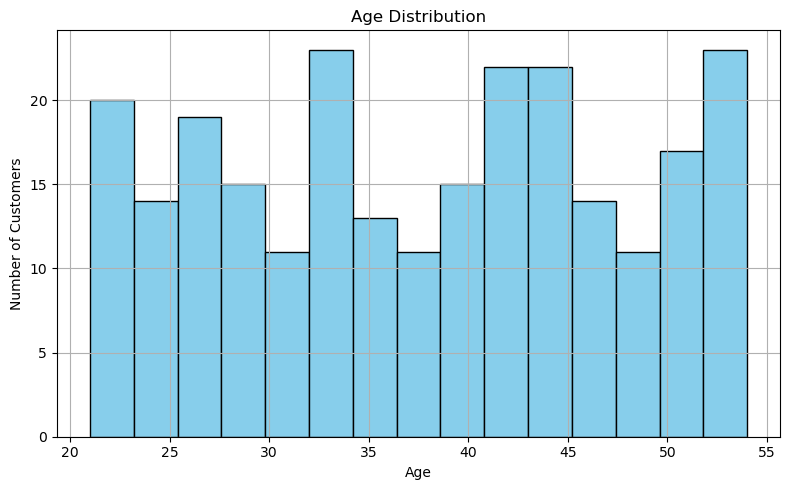

In [61]:
plt.figure(figsize=(8,5))
df['Age'].hist(bins=15, color='skyblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.savefig(r"C:\AIml_intern\reports\age_distribution.png")
plt.tight_layout()
plt.show()

Most customers fall between age 25 and 40, indicating a young-to-middle-aged customer base.

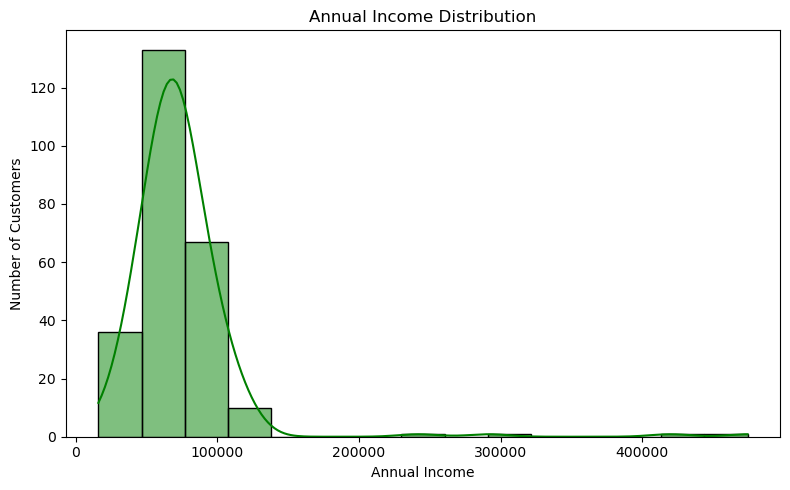

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df['AnnualIncome'], kde=True, color='green', bins=15)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")
plt.savefig(r"C:\AIml_intern\reports\income_distribution.png")
plt.tight_layout()
plt.show()

Income is slightly right skewed with a few high-income customers.

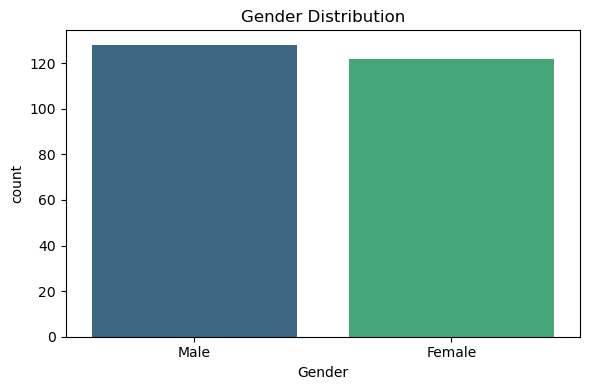

In [65]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, hue='Gender', palette='viridis', dodge=False)
plt.title("Gender Distribution")
plt.tight_layout()
plt.savefig(r"C:\AIml_intern/reports/gender_distribution.png")
plt.show()

The dataset contains slightly more male customers than male customers.

In [56]:
df['Gender'].value_counts()

Gender
Male      128
Female    122
Name: count, dtype: int64

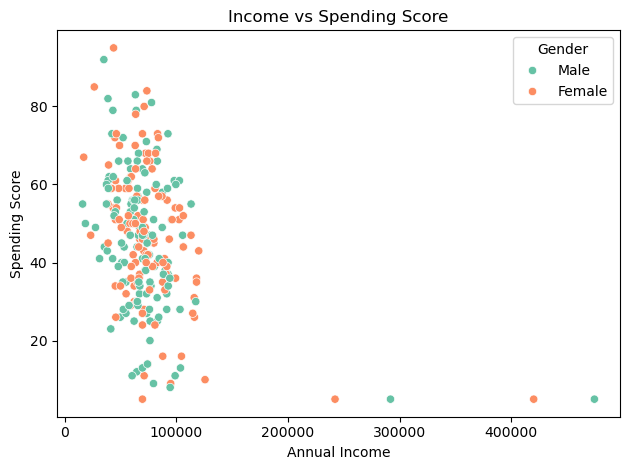

In [70]:
sns.scatterplot(x='AnnualIncome', y='SpendingScore', data=df, hue='Gender', palette='Set2')
plt.title("Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.tight_layout()
plt.savefig("../reports/income_vs_spending.png")
plt.show()

Customers with higher income generally tend to have higher spending scores, indicating a positive relationship between income and spending behavior.

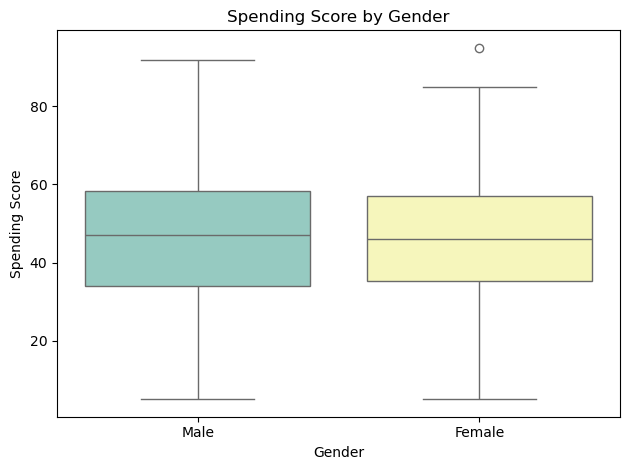

In [72]:
sns.boxplot(x='Gender', y='SpendingScore', data=df, hue='Gender', palette='Set3', legend=False)
plt.title("Spending Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Spending Score")
plt.savefig("../reports/spending_by_gender.png")
plt.tight_layout()
plt.show()

Spending patterns vary slightly across gender groups.  
Boxplot shows median spending scores are similar, but males show slightly wider spread in spending.

## Phase 4 — Correlation Heatmap & Executive Summary

**Goal:** Synthesize findings into a cohesive narrative.  
We will explore relationships between multiple variables and summarize top insights.

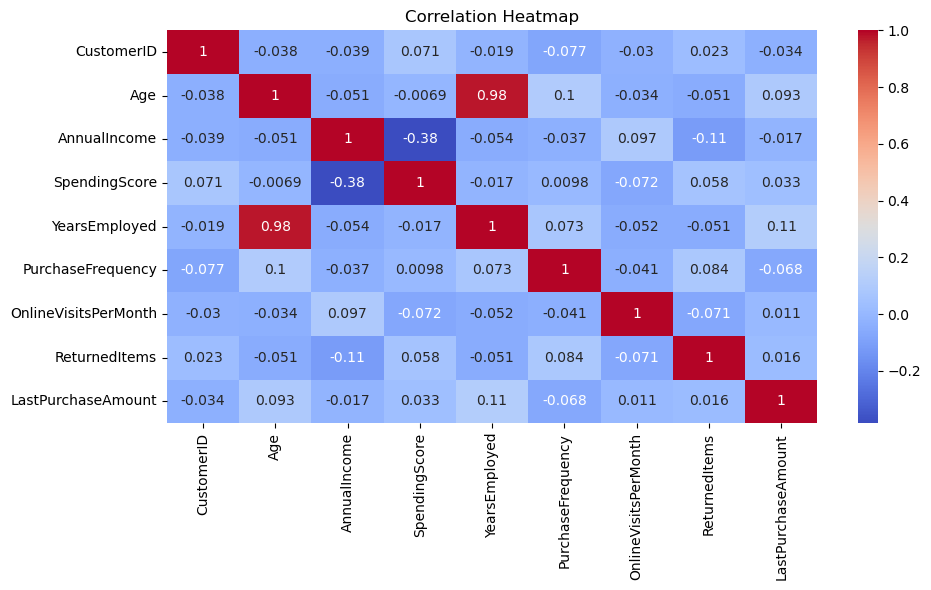

In [75]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(r"C:\AIml_intern\reports\correlation_heatmap.png")  # save for report
plt.show()

The heatmap shows relationships between numerical features.  
- Annual Income has a slight positive correlation with Spending Score.  
- Years Employed is slightly correlated with Annual Income.  
- Other features show weak or no correlation, indicating independent behavior.

# Executive Summary

**Key Insights:**

1. Higher income customers tend to have higher spending scores.
2. The majority of customers are between ages 25–40.
3. A few outliers exist in annual income which may affect modeling.